**Only dataset analysis and observation is there**

Import Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


Load the California Housing dataset

In [2]:
df = pd.read_csv('../dataset/raw/housing.csv')
print(df.head(10))
print('shape of the dataframe: ', df.shape)

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

# **Steps to Follow the EDA on the Given dataset**



**Step1. Identify the Target Column**
 
Our Goal is to predict the prize. Target Column is Prize

Visualize the target Column 

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


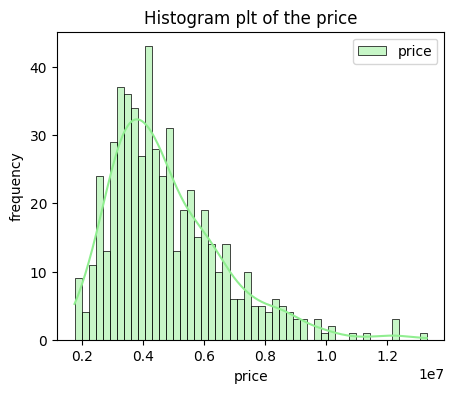

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns

print(df.columns)

plt.figure(figsize=(5,4))
sns.histplot(df['price'], label="price", bins=50, kde=True, color='lightgreen')
plt.xlabel("price")
plt.ylabel("frequency")
plt.title(f"Histogram plt of the {'price'}")
plt.legend()



Histplot of the Prize column is right skewed. 



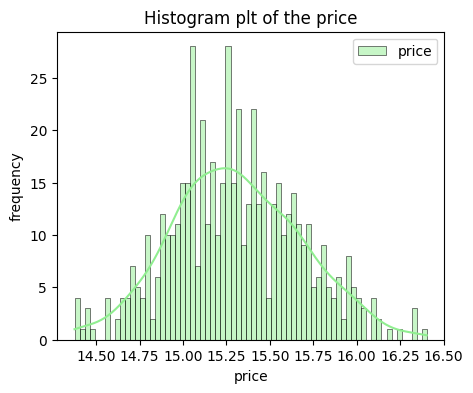

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

# Convert the right skewed prize column into a Normal Distribution curve
df['price'] = np.log1p(df['price'])

plt.figure(figsize=(5,4))
sns.histplot(df['price'], label="price", bins=70, kde=True, color='lightgreen')
plt.xlabel("price")
plt.ylabel("frequency")
plt.title(f"Histogram plt of the {'price'}")
plt.legend()

# Outlier check is pending

**Step 2. Missing Value Analysis**

In [5]:
# Check Null Values inside the dataset 

# No null Value is there in each column and no need to do further
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Step3. Check Duplicate Row**

In [6]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

**Step4. Numerical Feature EDA**

Filter out the Numerical column and categorical column

In [7]:
# Check the datatype of each feature(column)
df.info()
print(len(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    float64
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB
13


In [8]:
# -----------------------------------------------------------------------------
# =================== || Filtered Numerical and Categorical Column || =====================
# -----------------------------------------------------------------------------
numerical_feature = df.select_dtypes("int64")
categorical_feature = df.select_dtypes("object")

print('Numerical features: ', numerical_feature.columns)

print('Categorical Feature: ', categorical_feature.columns)

Numerical features:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
Categorical Feature:  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


**Step5. Coorelation Analysis**

In [9]:
# -----------------------------------------------------------------------------
# =================== || COORELATION MATRIX || =====================
# -----------------------------------------------------------------------------
correlationMatrix = df.select_dtypes(include='number').corr()

print(correlationMatrix)

# In the below table there is no extremely low correlated column. All are affecting the prize so no need to remove.

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.543233  0.369986   0.485715  0.415281  0.371638
area       0.543233  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.369986  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.485715  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.415281  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.371638  0.352980  0.139270   0.177496  0.045547  1.000000


Analysis of the Categorical feature column 

In [10]:
# -----------------------------------------------------------------------------
# =================== || CATEGORICAL COLUMNS ANALYSIS || =====================
# -----------------------------------------------------------------------------

categorical_feature = df.select_dtypes("object")

for col in categorical_feature.columns:
    means = df.groupby(col)['price'].mean() 
    print(f'{col}: ',means )
    print('difference: ',means.max()- means.min())
    print('-')

# -----------------------------------------------------------------------------
# difference:
# Difference	Interpretation
# > 0.30	Strong feature
# 0.15 - 0.30	Moderate
# < 0.15	Weak

# ------------------------------------------------------------------------------
# so we are removing the hotwaterheating columns
# ------------------------------------------------------------------------------

mainroad:  mainroad
no     15.004448
yes    15.356764
Name: price, dtype: float64
difference:  0.35231639709597573
-
guestroom:  guestroom
no     15.259054
yes    15.528370
Name: price, dtype: float64
difference:  0.26931573275613196
-
basement:  basement
no     15.247338
yes    15.417542
Name: price, dtype: float64
difference:  0.17020409412752358
-
hotwaterheating:  hotwaterheating
no     15.299734
yes    15.457857
Name: price, dtype: float64
difference:  0.1581237342915749
-
airconditioning:  airconditioning
no     15.192063
yes    15.556211
Name: price, dtype: float64
difference:  0.36414817591928994
-
prefarea:  prefarea
no     15.236831
yes    15.535541
Name: price, dtype: float64
difference:  0.2987100441017674
-
furnishingstatus:  furnishingstatus
furnished         15.450529
semi-furnished    15.359890
unfurnished       15.126622
Name: price, dtype: float64
difference:  0.3239070488886746
-


Drop a weak Column

In [11]:
df.drop(columns=['hotwaterheating'], inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    float64
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   airconditioning   545 non-null    object 
 9   parking           545 non-null    int64  
 10  prefarea          545 non-null    object 
 11  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 51.2+ KB
None


# Feature Scaling

In [12]:
# Follow Standard Scaler
print(df.head(10))

       price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  16.403275   7420         4          2        3      yes        no       no   
1  16.321037   8960         4          4        4      yes        no       no   
2  16.321037   9960         3          2        2      yes        no      yes   
3  16.318175   7500         4          2        2      yes        no      yes   
4  16.250001   7420         4          1        2      yes       yes      yes   
5  16.199676   7500         3          3        1      yes        no      yes   
6  16.132984   8580         4          3        4      yes        no       no   
7  16.132984  16200         5          3        2      yes        no       no   
8  16.105011   8100         4          1        2      yes       yes      yes   
9  16.097893   5750         3          2        4      yes       yes       no   

  airconditioning  parking prefarea furnishingstatus  
0             yes        2      yes        furnished 

Convert Categorical Data into Numerical Data

categorical columns = ['mainroad', 'guestroom', 'basement', 'airconditioning', 'prefarea', 'furnishingsatus']

Only furnishingsatus is Ordinal columns unfurnished < semi furnished < Furnished
Other are only Nominal Columns

For Nominal Categorical Columns: One Hot Encoding 
For Ordinal Categorical Columns: 

Apply Binary Encoding in the binary Column


In [13]:
binary_col = df.select_dtypes("object").drop(columns=['furnishingstatus']).columns
# print(binary_col)

print(binary_col)

ordinal_col = ['furnishingstatus']
print(ordinal_col)



Index(['mainroad', 'guestroom', 'basement', 'airconditioning', 'prefarea'], dtype='object')
['furnishingstatus']


In [14]:
# Apply Binary Encoding or One HOT Encoding in the Binary Column

from sklearn.preprocessing import OrdinalEncoder

# Create an Ordinal
binaryEncoder = OrdinalEncoder(categories=[['no', 'yes']]*len(binary_col))

print(binaryEncoder)
print(df[binary_col].head(8))
df[binary_col] = binaryEncoder.fit_transform(df[binary_col])
print(df[binary_col].head(8))


OrdinalEncoder(categories=[['no', 'yes'], ['no', 'yes'], ['no', 'yes'],
                           ['no', 'yes'], ['no', 'yes']])
  mainroad guestroom basement airconditioning prefarea
0      yes        no       no             yes      yes
1      yes        no       no             yes       no
2      yes        no      yes              no      yes
3      yes        no      yes             yes      yes
4      yes       yes      yes             yes       no
5      yes        no      yes             yes      yes
6      yes        no       no             yes      yes
7      yes        no       no              no       no
   mainroad  guestroom  basement  airconditioning  prefarea
0       1.0        0.0       0.0              1.0       1.0
1       1.0        0.0       0.0              1.0       0.0
2       1.0        0.0       1.0              0.0       1.0
3       1.0        0.0       1.0              1.0       1.0
4       1.0        1.0       1.0              1.0       0.0
5       1.0    

**Apply Ordinal Encoding on the "furnishingstatus" columns**

In [15]:
# Ordinal Encoding on the furnishingstatus column

from sklearn.preprocessing import OrdinalEncoder

furnishingEncoder = OrdinalEncoder(categories=[['unfurnished',
                           'semi-furnished',
                           'furnished']])


df[['furnishingstatus']] = furnishingEncoder.fit_transform(df[['furnishingstatus']])

print(df.head(10))

       price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  16.403275   7420         4          2        3       1.0        0.0   
1  16.321037   8960         4          4        4       1.0        0.0   
2  16.321037   9960         3          2        2       1.0        0.0   
3  16.318175   7500         4          2        2       1.0        0.0   
4  16.250001   7420         4          1        2       1.0        1.0   
5  16.199676   7500         3          3        1       1.0        0.0   
6  16.132984   8580         4          3        4       1.0        0.0   
7  16.132984  16200         5          3        2       1.0        0.0   
8  16.105011   8100         4          1        2       1.0        1.0   
9  16.097893   5750         3          2        4       1.0        1.0   

   basement  airconditioning  parking  prefarea  furnishingstatus  
0       0.0              1.0        2       1.0               2.0  
1       0.0              1.0        3       0.0  

In [16]:
# Change the datatype of the columns

df.info()

columns = df.drop(columns=['price']).columns
# newdf = df.copy()
for col in columns:
    if df[col].dtype == 'float' :
        df[col] = df[col].astype(int)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    float64
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    float64
 6   guestroom         545 non-null    float64
 7   basement          545 non-null    float64
 8   airconditioning   545 non-null    float64
 9   parking           545 non-null    int64  
 10  prefarea          545 non-null    float64
 11  furnishingstatus  545 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 51.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            -----------

In [17]:
print(df.head(10))

       price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  16.403275   7420         4          2        3         1          0   
1  16.321037   8960         4          4        4         1          0   
2  16.321037   9960         3          2        2         1          0   
3  16.318175   7500         4          2        2         1          0   
4  16.250001   7420         4          1        2         1          1   
5  16.199676   7500         3          3        1         1          0   
6  16.132984   8580         4          3        4         1          0   
7  16.132984  16200         5          3        2         1          0   
8  16.105011   8100         4          1        2         1          1   
9  16.097893   5750         3          2        4         1          1   

   basement  airconditioning  parking  prefarea  furnishingstatus  
0         0                1        2         1                 2  
1         0                1        3         0  

# ***Training of the Model***

In [18]:
# Separate the Input and Target Columns

X = df.drop(columns=['price']) # Input Features
Y = df['price'] # Target Features

print('X Input Feature: \n',X)
print('Output Column: \n',Y)

X Input Feature: 
      area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     airconditioning  parking  prefarea  furnishingstatus  
0                  1        2   

Split the Training and Testing Data

In [19]:
# Train Test Split

# Import Library 
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [20]:
# print the detail of the trainig and testing data

print(df.shape)

print('-'*100)

print(X_train.shape)
print(X_train)

print('-'*100)

print(X_test.shape)
print(X_test)

(545, 12)
----------------------------------------------------------------------------------------------------
(436, 11)
     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
412  2610         3          1        2         1          0         1   
284  7770         2          1        1         1          0         0   
504  3185         2          1        1         1          0         0   
209  6720         3          1        1         1          0         0   
269  3900         3          1        2         1          0         0   
..    ...       ...        ...      ...       ...        ...       ...   
299  7000         3          1        1         1          0         0   
534  3000         4          1        2         1          0         0   
493  3960         3          1        1         1          0         0   
527  1836         2          1        1         0          0         1   
168  4260         4          1        2         1          0     

Apply Standard Scaler (data is not in same scale like area feature and other)

In [21]:
# Standard Scaler

# Import Standard Scaler
from sklearn.preprocessing import StandardScaler

# Create StandardScaler Object
scaler = StandardScaler()

# Scaled X_train data 
X_train_scaled = scaler.fit_transform(X_train)

# Scaled X_test data based on rules learn on training data like mean
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print("-"*100)
print(X_test_scaled)

[[-1.17687206  0.03201512 -0.58376171 ... -0.78680611  1.78670302
  -1.21990719]
 [ 1.23991283 -1.36384432 -0.58376171 ...  0.40020934 -0.5596901
   1.40665841]
 [-0.90755979 -1.36384432 -0.58376171 ... -0.78680611 -0.5596901
  -1.21990719]
 ...
 [-0.54457369  0.03201512 -0.58376171 ... -0.78680611 -0.5596901
   1.40665841]
 [-1.53938979 -1.36384432 -0.58376171 ... -0.78680611 -0.5596901
   0.09337561]
 [-0.40406294  1.42787457 -0.58376171 ... -0.78680611 -0.5596901
   1.40665841]]
----------------------------------------------------------------------------------------------------
[[-0.99420808  0.03201512 -0.58376171 ... -0.78680611 -0.5596901
   0.09337561]
 [-0.63824752  0.03201512 -0.58376171 ...  1.58722478 -0.5596901
   0.09337561]
 [-0.55862476 -1.36384432 -0.58376171 ... -0.78680611 -0.5596901
  -1.21990719]
 ...
 [ 1.5911897   0.03201512 -0.58376171 ...  1.58722478 -0.5596901
   1.40665841]
 [ 0.09240838  0.03201512 -0.58376171 ... -0.78680611  1.78670302
   0.09337561]
 [ 0.4

***Trained the Linear Regression Model***

In [22]:
# Import Linear Regression Module

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, Y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
# Model Prediction

Y_pred = model.predict(X_test_scaled)
print('X Test\n',X_test)
print('-'*100)

# Target Price Predicted value for test data
# we need to log this data
print('Y prediction\n',Y_pred)
print(len(Y_pred))

# Target Price Actual Value for test data. 
print('-'*100)
print('Y Test\n', Y_test)

X Test
      area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
333  3000         3          1        2         1          0         0   
84   3760         3          1        2         1          0         0   
439  3930         2          1        1         0          0         0   
396  3640         2          1        1         1          0         0   
161  6100         3          1        3         1          1         0   
..    ...       ...        ...      ...       ...        ...       ...   
100  6600         3          2        1         1          0         1   
344  3850         2          1        1         1          0         0   
176  8520         3          1        1         1          0         0   
244  5320         3          1        2         1          1         1   
15   6000         4          1        2         1          0         1   

     airconditioning  parking  prefarea  furnishingstatus  
333                0        0         0    

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error: ", mean_absolute_error(Y_test, Y_pred))
print("Mean squared Error: ", mean_squared_error(Y_test, Y_pred))
print("R2 Score: ", r2_score(Y_test, Y_pred))

Mean Absolute Error:  0.17916145972979405
Mean squared Error:  0.05098993655714576
R2 Score:  0.616112641607504
